# Supermarket Sales Analysis
### Data Analytics & AI Internship Project

**Objective:** Analyze historical supermarket transaction data (500 records) to uncover customer purchasing behavior, product performance, branch profitability, and payment preferences, and to generate actionable business recommendations.

**Track:** Business Intelligence / Exploratory Data Analysis
**Tools:** Python, Pandas, NumPy, Matplotlib


## 1. Data Collection & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('supermarket_sales_clean.csv', parse_dates=['Date'])
df.head()

,InvoiceID,Date,Branch,City,CustomerType,Gender,Product,Category,Quantity,UnitPrice,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [2]:
df.shape

(500, 13)

## 2. Data Cleaning & Quality Checks

Before analysis, we verify the dataset for missing values, duplicate records, correct data types, and formatting consistency.

In [3]:
# Check for missing values
df.isnull().sum()

InvoiceID       0
Date            0
Branch          0
City            0
CustomerType    0
Gender          0
Product         0
Category        0
Quantity        0
UnitPrice       0
Payment         0
Rating          0
Sales           0
dtype: int64

In [4]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Invoice IDs:", df['InvoiceID'].duplicated().sum())

Duplicate rows: 0
Duplicate Invoice IDs: 0


In [5]:
# Data types
df.dtypes

InvoiceID                  str
Date            datetime64[us]
Branch                     str
City                       str
CustomerType               str
Gender                     str
Product                    str
Category                   str
Quantity                 int64
UnitPrice              float64
Payment                    str
Rating                 float64
Sales                  float64
dtype: object

In [6]:
# Basic descriptive statistics
df.describe()

,Date,Quantity,UnitPrice,Rating,Sales
count,500,500.000000,500.000000,500.000000,500.000000
mean,2026-04-03 12:25:55.200000,5.536000,88.660700,3.994400,488.822160
min,2026-01-01 00:00:00,1.000000,27.670000,3.000000,28.610000
25%,2026-02-17 00:00:00,3.000000,43.955000,3.500000,189.212500
50%,2026-04-09 00:00:00,5.500000,61.880000,4.000000,335.910000
75%,2026-05-17 06:00:00,8.000000,128.567500,4.500000,609.885000
max,2026-07-01 00:00:00,10.000000,236.710000,5.000000,2114.820000
std,NaN,2.875629,57.284029,0.574481,437.327833


**Cleaning summary:** The dataset contains 500 transaction records across 13 columns with **no missing values** and **no duplicate rows or invoice IDs**. All data types are correctly inferred (dates as datetime, quantities as integers, prices/ratings/sales as floats). No cleaning corrections were required beyond type casting.

## 3. Feature Engineering

Total Sales is validated using the formula:

138Sales = Quantity \times UnitPrice138

In [7]:
df['Sales_calc'] = df['Quantity'] * df['UnitPrice']
mismatch = (df['Sales'] - df['Sales_calc']).abs() > 0.5
print(f"Rows where Sales != Quantity x UnitPrice (tolerance 0.5): {mismatch.sum()}")
df.drop(columns=['Sales_calc'], inplace=True)

Rows where Sales != Quantity x UnitPrice (tolerance 0.5): 0


## 4. Exploratory Data Analysis

### 4.1 Which product generates the highest sales?

In [8]:
by_product = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)
by_product.head(10)

Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Name: Sales, dtype: float64

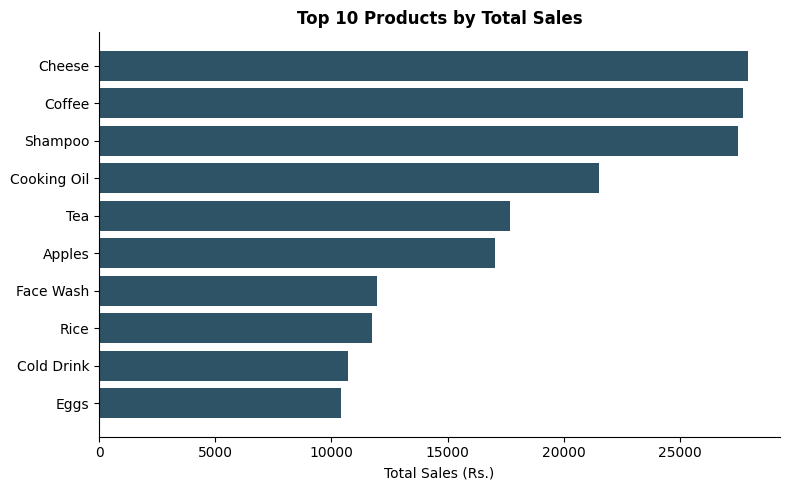

In [9]:
fig, ax = plt.subplots()
top10 = by_product.head(10).sort_values()
ax.barh(top10.index, top10.values, color='#2E5266')
ax.set_title('Top 10 Products by Total Sales', fontweight='bold')
ax.set_xlabel('Total Sales (Rs.)')
plt.tight_layout()
plt.show()

**Insight:** Cheese generates the highest total sales (Rs. 27,906.30), followed by other high-unit-price Dairy and Personal Care items. High-ticket, lower-frequency purchases dominate revenue leadership.

### 4.2 Which branch performs best?

In [10]:
by_branch = df.groupby(['Branch','City'])['Sales'].sum().sort_values(ascending=False)
by_branch

Branch  City     
C       Mumbai       72469.45
B       Delhi        64116.26
D       Bengaluru    55468.29
A       Jaipur       52357.08
Name: Sales, dtype: float64

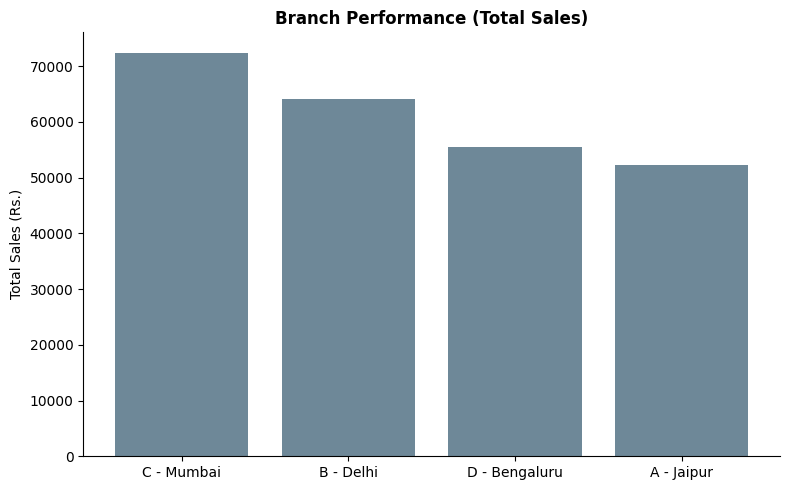

In [11]:
fig, ax = plt.subplots()
labels = [f"{b} - {c}" for (b,c) in by_branch.index]
ax.bar(labels, by_branch.values, color='#6E8898')
ax.set_title('Branch Performance (Total Sales)', fontweight='bold')
ax.set_ylabel('Total Sales (Rs.)')
plt.tight_layout()
plt.show()

**Insight:** Branch C (Mumbai) is the top performer with Rs. 72,469.45 in sales, ~13% ahead of Branch B (Delhi). Branch A (Jaipur) trails all branches.

### 4.3 Which category sells the most?

In [12]:
by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
by_category

Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64

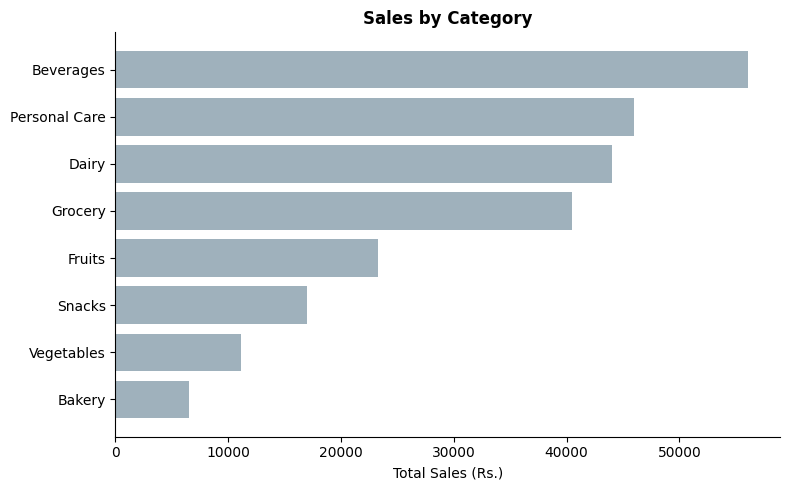

In [13]:
fig, ax = plt.subplots()
bc = by_category.sort_values()
ax.barh(bc.index, bc.values, color='#9FB1BC')
ax.set_title('Sales by Category', fontweight='bold')
ax.set_xlabel('Total Sales (Rs.)')
plt.tight_layout()
plt.show()

**Insight:** Beverages is the top-selling category (Rs. 56,108.24), ahead of Personal Care and Dairy. Bakery and Vegetables are the smallest contributors — likely due to lower unit prices.

### 4.4 What is the most popular payment method?

In [14]:
by_payment = df['Payment'].value_counts()
by_payment

Payment
UPI            127
Net Banking    126
Card           125
Cash           122
Name: count, dtype: int64

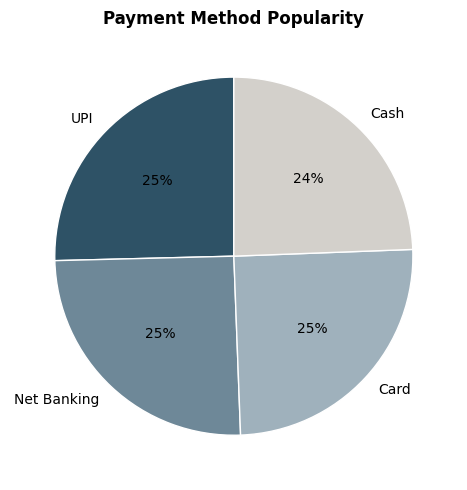

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
ax.pie(by_payment.values, labels=by_payment.index, autopct='%1.0f%%', startangle=90,
       colors=['#2E5266','#6E8898','#9FB1BC','#D3D0CB'], wedgeprops={'edgecolor':'white'})
ax.set_title('Payment Method Popularity', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** UPI is the most-used payment method (127 transactions, 25.4%), narrowly ahead of Net Banking (126), Card (125), and Cash (122). Digital payments (UPI + Net Banking + Card) account for 75.6% of all transactions.

### 4.5 Do Members spend more than Normal customers?

In [16]:
by_custtype = df.groupby('CustomerType')['Sales'].agg(['mean','sum','count']).round(2)
by_custtype

,mean,sum,count
CustomerType,,,
Member,483.14,143009.30,296
Normal,497.07,101401.78,204


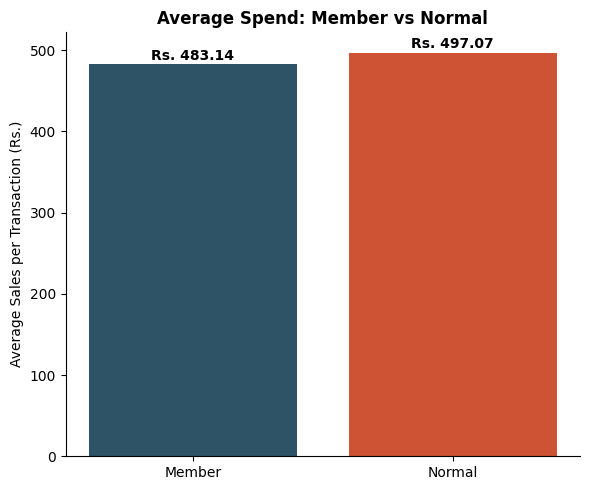

In [17]:
fig, ax = plt.subplots(figsize=(6,5))
ax.bar(by_custtype.index, by_custtype['mean'], color=['#2E5266','#CD5334'])
ax.set_title('Average Spend: Member vs Normal', fontweight='bold')
ax.set_ylabel('Average Sales per Transaction (Rs.)')
for i, v in enumerate(by_custtype['mean']):
    ax.text(i, v + 5, f'Rs. {v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** No — Normal customers spend slightly more per transaction on average (Rs. 497.07) than Members (Rs. 483.14). However, Members generate 41% more total transactions (296 vs 204), so they still contribute more total revenue (Rs. 143,009 vs Rs. 101,402) through purchase frequency, not basket size.

### 4.6 What is the average customer rating?

In [18]:
avg_rating = df['Rating'].mean()
print(f"Average rating: {avg_rating:.2f} / 5")
df['Rating'].describe()

Average rating: 3.99 / 5


count    500.000000
mean       3.994400
std        0.574481
min        3.000000
25%        3.500000
50%        4.000000
75%        4.500000
max        5.000000
Name: Rating, dtype: float64

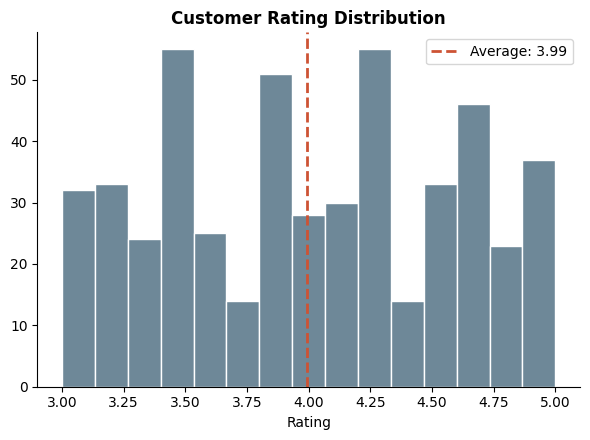

In [19]:
fig, ax = plt.subplots(figsize=(6,4.5))
ax.hist(df['Rating'], bins=15, color='#6E8898', edgecolor='white')
ax.axvline(avg_rating, color='#CD5334', linestyle='--', linewidth=2, label=f'Average: {avg_rating:.2f}')
ax.set_title('Customer Rating Distribution', fontweight='bold')
ax.set_xlabel('Rating')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** The average customer rating is 3.99 out of 5 — solid but with room for improvement toward a 4.5+ benchmark.

### 4.7 Additional: Monthly sales trend

In [20]:
monthly = df.set_index('Date').resample('ME')['Sales'].sum()
monthly

Date
2026-01-31    43415.53
2026-02-28    30068.15
2026-03-31    37306.42
2026-04-30    52569.77
2026-05-31    42542.31
2026-06-30    35041.46
2026-07-31     3467.44
Freq: ME, Name: Sales, dtype: float64

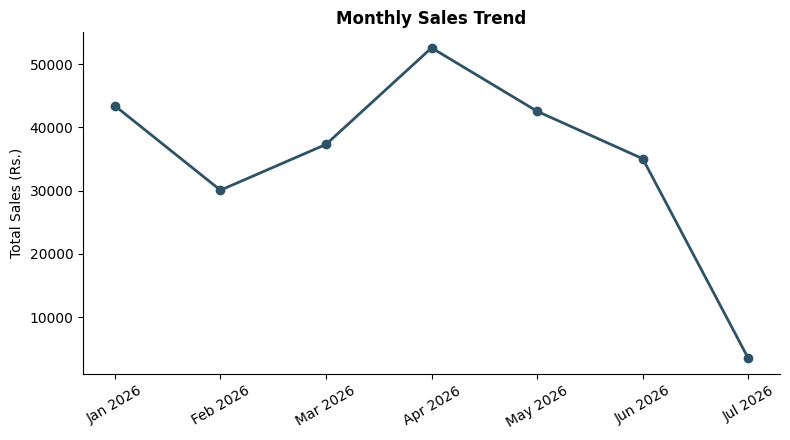

In [21]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(monthly.index.strftime('%b %Y'), monthly.values, marker='o', color='#2E5266', linewidth=2)
ax.set_title('Monthly Sales Trend', fontweight='bold')
ax.set_ylabel('Total Sales (Rs.)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:** Sales peak in April (Rs. 52,569.77) and dip in February. July is incomplete (only 1 day of data), explaining the sharp drop-off.

### 4.8 Additional: Rating by branch

In [22]:
rating_by_branch = df.groupby(['Branch','City'])['Rating'].mean().sort_values(ascending=False).round(3)
rating_by_branch

Branch  City     
D       Bengaluru    4.092
C       Mumbai       4.046
B       Delhi        3.975
A       Jaipur       3.837
Name: Rating, dtype: float64

**Insight:** Branch D (Bengaluru) has the highest average customer rating (4.09) despite not being the top revenue branch, while Branch A (Jaipur) has both the lowest sales and the lowest rating (3.84) — suggesting a service quality issue may be suppressing its performance.

## 5. Business Recommendations

Based on the analysis above:

1. **Optimize inventory around high-performers.** Stock up on Cheese, other Dairy items, and Beverages (the top category) ahead of peak months (April) to avoid stockouts and capture demand.
2. **Study and replicate Branch C's (Mumbai) success.** Investigate its product mix, staffing, and local marketing, and apply learnings to Branch A (Jaipur), the weakest performer on both sales and rating.
3. **Strengthen the digital payment experience.** UPI is already the top method; ensure UPI/Net Banking/Card infrastructure (uptime, speed, cashback tie-ins) stays reliable, since 76% of transactions are already cashless.
4. **Grow membership frequency, not just headcount.** Members already visit more often than Normal customers; incentivize higher basket size per visit (bundle deals, cross-category coupons) since Normal customers currently out-spend Members per transaction.
5. **Investigate the service gap at Branch A.** Its below-average rating (3.84) alongside lowest sales suggests operational or staffing issues worth a manager-level review, potentially through mystery-shopper audits or staff retraining.
6. **Target a rating uplift program.** With average rating at 3.99, a modest investment in checkout speed, staff training, or store layout could push ratings past the 4.5 threshold, likely correlating with repeat visits.


## 6. Extended Analysis

### 6.1 Sales by Gender

In [23]:
by_gender = df.groupby("Gender")["Sales"].agg(["sum","mean","count"]).round(2)
by_gender

,sum,mean,count
Gender,,,
Female,123954.12,486.09,255
Male,120456.96,491.66,245


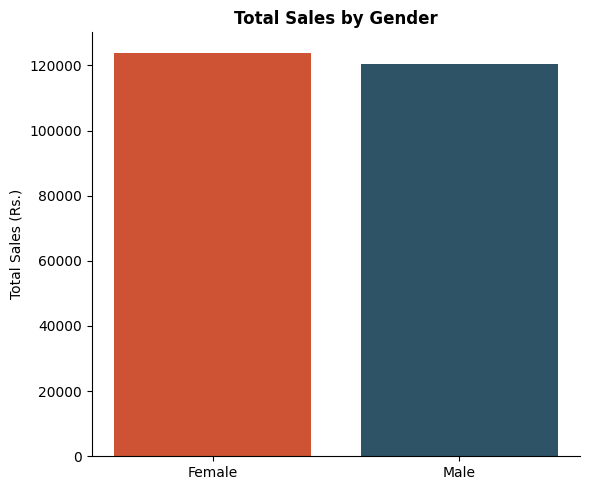

In [24]:
fig, ax = plt.subplots(figsize=(6,5))
ax.bar(by_gender.index, by_gender["sum"], color=["#CD5334","#2E5266"])
ax.set_title("Total Sales by Gender", fontweight="bold")
ax.set_ylabel("Total Sales (Rs.)")
plt.tight_layout()
plt.show()

**Insight:** Sales are almost evenly split by gender (Female Rs. 1,23,954 vs Male Rs. 1,20,457) — gender is not a meaningful driver of revenue here, so marketing need not be gender-segmented.

### 6.2 Sales by Day of Week

In [25]:
df["DayOfWeek"] = df["Date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_dow = df.groupby("DayOfWeek")["Sales"].sum().reindex(order)
by_dow

DayOfWeek
Monday       42602.44
Tuesday      36293.23
Wednesday    34363.73
Thursday     28576.26
Friday       33026.36
Saturday     32829.15
Sunday       36719.91
Name: Sales, dtype: float64

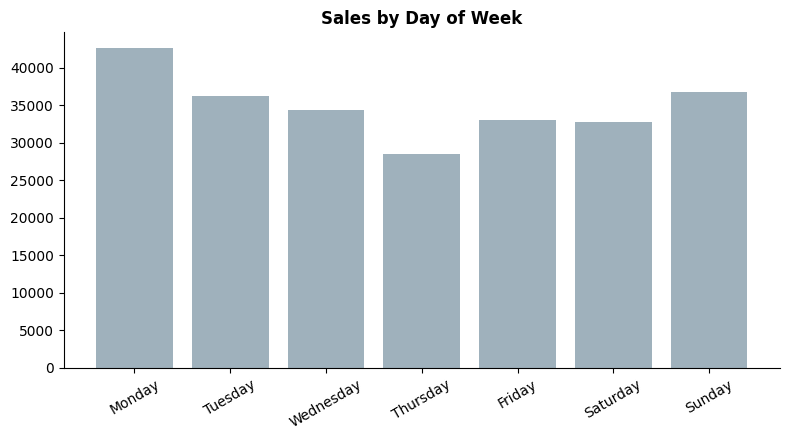

In [26]:
fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(by_dow.index, by_dow.values, color="#9FB1BC")
ax.set_title("Sales by Day of Week", fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:** Monday is the strongest sales day (Rs. 42,602), possibly a start-of-week stock-up pattern; Thursday is the weakest (Rs. 28,576). This can inform staffing schedules and targeted weekday promotions.

### 6.3 Correlation Analysis

In [27]:
corr = df[["Quantity","UnitPrice","Rating","Sales"]].corr()
corr.round(3)

,Quantity,UnitPrice,Rating,Sales
Quantity,1.000,-0.012,0.001,0.573
UnitPrice,-0.012,1.000,-0.089,0.722
Rating,0.001,-0.089,1.000,-0.047
Sales,0.573,0.722,-0.047,1.000


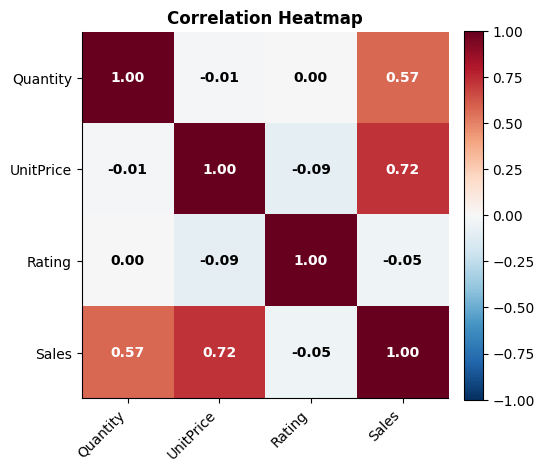

In [28]:
fig, ax = plt.subplots(figsize=(5.5,5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr.iloc[i,j])>0.5 else "black", fontweight="bold")
ax.set_title("Correlation Heatmap", fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**Insight:** Sales correlates most strongly with Unit Price (0.72) and Quantity (0.57) — as expected, since Sales is derived from both. Rating shows almost no correlation with Sales (-0.05), confirming that satisfaction and revenue are driven by different factors and should be tracked as separate KPIs.

### 6.4 Branch x Category Breakdown

In [29]:
pivot = df.groupby(["Branch","Category"])["Sales"].sum().unstack().fillna(0)
pivot.round(0)

Category,Bakery,Beverages,Dairy,Fruits,Grocery,Personal Care,Snacks,Vegetables
Branch,,,,,,,,
A,1860.0,7934.0,10675.0,4986.0,9278.0,12119.0,2995.0,2510.0
B,1990.0,18218.0,10516.0,8626.0,6751.0,11426.0,3565.0,3025.0
C,1130.0,11638.0,16203.0,7306.0,13255.0,15312.0,4803.0,2822.0
D,1535.0,18318.0,6598.0,2345.0,11187.0,7087.0,5630.0,2767.0


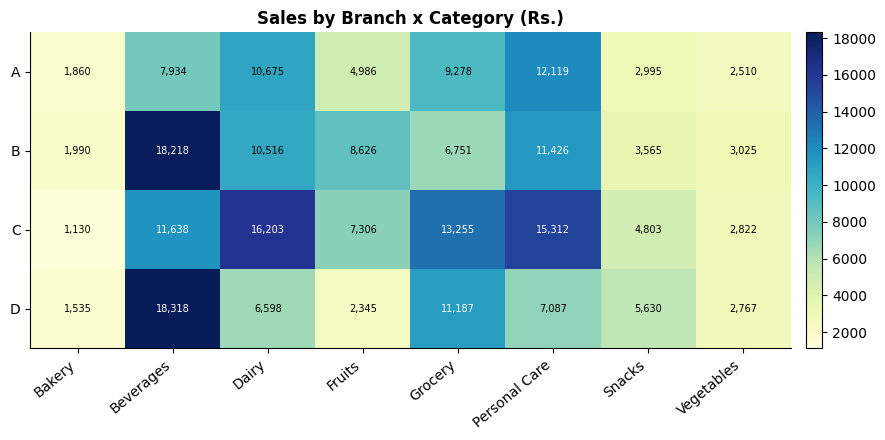

In [30]:
fig, ax = plt.subplots(figsize=(9,4.5))
im = ax.imshow(pivot.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=40, ha="right")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        ax.text(j, i, f"{val:,.0f}", ha="center", va="center", fontsize=7,
                 color="white" if val > pivot.values.max()*0.6 else "black")
ax.set_title("Sales by Branch x Category (Rs.)", fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

**Insight:** Branch C (Mumbai) leads specifically in Dairy and Personal Care, while Branch D (Bengaluru) and Branch B (Delhi) lead in Beverages. Branch A (Jaipur) has no standout category — a sign its underperformance is broad rather than concentrated in one area, reinforcing the case for a full operational review.

### 6.5 Unit Price vs Sales, by Category

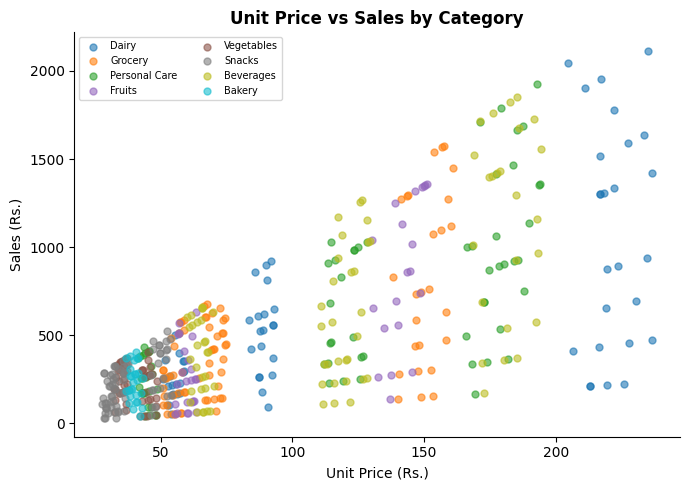

In [31]:
fig, ax = plt.subplots(figsize=(7,5))
cats = df["Category"].unique()
colors = plt.cm.tab10(np.linspace(0,1,len(cats)))
for cat, c in zip(cats, colors):
    sub = df[df["Category"]==cat]
    ax.scatter(sub["UnitPrice"], sub["Sales"], label=cat, alpha=0.6, s=25, color=c)
ax.set_xlabel("Unit Price (Rs.)")
ax.set_ylabel("Sales (Rs.)")
ax.set_title("Unit Price vs Sales by Category", fontweight="bold")
ax.legend(fontsize=7, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

**Insight:** Personal Care and Dairy occupy the higher unit-price band and naturally cluster toward higher sales values, while Vegetables, Bakery, and Snacks sit in the low-price, low-ticket cluster. This confirms basket value is driven more by product pricing tier than by category popularity alone.